# Harmadik projekt

# F1

Oldja meg a következő kezdeti érték feladatot a javított-Euler módszerrel $10,20,50$ lépést használva, ábrázolja és az eredményt hasonlítsa össze az `ode23` által adott-tal:

$$
   y''+y'-ty=t+1\\
$$
$$
y(1)=2\\
$$
$$
y'(1)=0\\
$$
$$
y(2)=?
$$


In [1]:
%%file "EulerImp.m"

% javított Euler módszer
function [t,y]=EulerImp(F,tr,y0,lepes)
  t=linspace(tr(1),tr(2),lepes+1);
  y=zeros(2,lepes+1);
  h=t(2)-t(1);
  y(:,1)=y0;
  for it=1:lepes
    k1 = F(t(it),y(:,it));
    k2 = F(t(it)+h,y(:,it)+k1*h);
    y(:,it+1)=y(:,it)+h*(k1+k2)/2;
  end
  t=t';
  y=y'; % hogy hasonloan lehessen hasznalni mint az ode*-okat
end

Created file '/home/nosy/Downloads/mm2_projektek/p3/EulerImp.m'.


In [2]:
f=@(t,y,dy) t+1+t*y-dy;

% a kapcsolódó rendszer jobboldala
F=@(t,v) [v(2); f(t,v(1),v(2))];


% kezdeti értékek
t0=1; tv=2; y0=[2;0];

[t10,y10]=EulerImp(F,[t0,tv],y0,10);
[t20,y20]=EulerImp(F,[t0,tv],y0,20);

[tode,yode]=ode23(F,[t0,tv],y0);





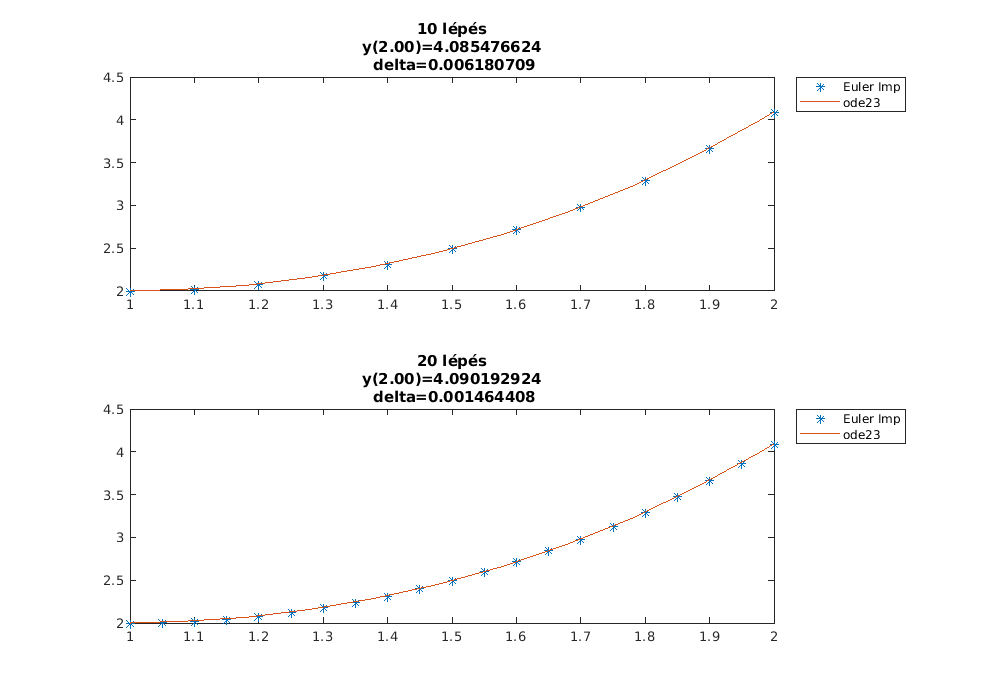

In [6]:
%plot -s 1000,700

% külön abrakat használva jobban látszik a módszer dinamikája

subplot(2,1,1);
plot(t10,y10(:,1),'*');
hold on;
plot(tode,yode(:,1));
legend("Euler Imp", "ode23",'location','northeastoutside');
title(sprintf("10 lépés\n y(%.2f)=%.9f \n delta=%.9f", tv, y10(end,1) ,abs(y10(end,1)-yode(end,1))));

subplot(2,1,2);
plot(t20,y20(:,1),'*');
hold on;
plot(tode,yode(:,1));
legend("Euler Imp", "ode23",'location','northeastoutside');
title(sprintf("20 lépés\n y(%.2f)=%.9f \n delta=%.9f", tv, y20(end,1) ,abs(y20(end,1)-yode(end,1))));

